# Colour Fringing Calculation (Geometric PSF Models)

This notebook demonstrates the **geometric-optics** route for predicting lateral colour fringing on a knife-edge target.

**Physical picture.** When an achromatic lens images a high-contrast edge, residual longitudinal chromatic aberration (CHL) causes each wavelength to focus at a slightly different axial position. At any given image plane $z$, each wavelength therefore produces a defocused disc whose radius depends on its focal shift $\mathrm{CHL}(\lambda)$. The RGB channels of a colour sensor integrate these discs with different spectral weights, producing channel-dependent Edge Spread Functions (ESFs). The spatial region where the R, G, B ESFs disagree is the **colour fringe**, and its width is the **Colour Fringe Width (CFW)**.

**Signal chain modelled here:**

$$\text{Scene (edge)} \;\xrightarrow{D_{65}}\; \text{Illuminant} \;\xrightarrow{\mathrm{CHL},\,\mathrm{SA}}\; \text{Lens} \;\xrightarrow{S_c(\lambda)}\; \text{Sensor (RGB)} \;\xrightarrow{\gamma,\,\alpha}\; \text{Display}$$

For the FFT-based diffraction PSF route, see [`cfw_fftpsf_demo.ipynb`](cfw_fftpsf_demo.ipynb).

In [24]:
# ───────────────────────────── Imports ─────────────────────────────
import sys
from pathlib import Path
from typing import Literal

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import FloatSlider

# Allow "import chromf …" without installing the package
sys.path.insert(0, str(Path("..").resolve() / "src"))

from chromf.spectrum_loader import _load_defocus, _load_daylight, _load_sensor, channel_products
from chromf.optiland_bridge import (
    compute_chl_curve,
    compute_rori_spot_curves,
    compute_w040_curve,
    precompute_ray_fan,
    compute_polychromatic_esf_geometric,
    compute_polychromatic_esf_fast,
)
from chromf.cfw import edge_rgb_response, fringe_width
from optiland import fileio
from optiland.physical_apertures import RadialAperture

## 1. Load Lens Model

Load a Zemax lens file and apply physical aperture constraints to each surface.

In [ ]:
lens1 = fileio.load_zemax_file(str(Path("..") / "data" / "lens" / "NikonAINikkor85mmf2S.zmx"))

clear_semi_diameters = [
    None, 25.062, 24.642, 21.225, 21.225, 19.006, 15.289,
    12.836, 13.730, 15.469, 16.188, 16.188, 17.088, 17.088, 21.190
]
for i, r in enumerate(clear_semi_diameters):
    if r is not None:
        lens1.surface_group.surfaces[i].aperture = RadialAperture(r_max=r)

print(f"FNO = {lens1.paraxial.FNO():.2f}, focal length = {lens1.paraxial.f2():.1f} mm")
lens1.draw(num_rays=7)

## 2. Precompute Aberration Data

For each wavelength $\lambda$ in the sensor grid, we extract four aberration quantities from the lens model:

| Quantity | Symbol | Definition | Source |
|----------|--------|------------|--------|
| **Paraxial CHL** | $\mathrm{CHL}_{\mathrm{par}}(\lambda)$ | $[f_2'(\lambda) - f_2'(\lambda_{\mathrm{ref}})]\times 10^3\;\mu\mathrm{m}$ | Marginal-ray trace (on-axis, infinitesimal aperture) |
| **RoRi CHL** | $\mathrm{CHL}_{\mathrm{RoRi}}(\lambda)$ | Weighted real-ray back-focal intercept averaged over 5 pupil zones | Aperture-dependent; includes spherochromatism |
| **Geometric spot radius** | $\rho_{\mathrm{SA}}(\lambda)$ | $\sqrt{\sum_i w_i \, y_{\mathrm{spot}}(\rho_i,\lambda)^2 / \sum_i w_i}$ | RMS residual transverse aberration at RoRi focus |
| **Seidel W040** | $W_{040}(\lambda)$ | $-\mathrm{TA}_{\mathrm{marginal}} \times 10^3 / (8N)$ | Primary spherical aberration coefficient ($\mu\mathrm{m}$ OPD) |

Here $N = f/D$ denotes the f-number.

**RoRi focus** is a weighted average of the real-ray back-focal distance $\mathrm{SK}(\rho,\lambda)$ at five pupil heights $\rho \in \{0,\;\sqrt{0.25},\;\sqrt{0.5},\;\sqrt{0.75},\;1\}$ with weights $\{1,\;12.8,\;14.4,\;12.8,\;1\}/42$.

The **ray fan** pre-computes signed transverse aberration $\mathrm{TA}_0(\rho,\lambda)$ and direction-cosine slope $m(\rho,\lambda)=M/N_{\mathrm{dir}}$ at $z=0$, enabling fast linear extrapolation to arbitrary defocus:

$$R(\rho;\,z,\lambda) = \left|\mathrm{TA}_0(\rho,\lambda) + m(\rho,\lambda)\cdot z\right| \qquad (\mu\mathrm{m})$$

In [26]:
# ──────────────────────────── Data load ────────────────────────────
prods = channel_products()
sensor_wl = prods["blue"][:, 0]   # nm — must match SENSOR_RESPONSE in cfw.py

if lens1 is not None:
    paraxial_curve              = compute_chl_curve(lens1, wavelengths_nm=sensor_wl)
    rori_curve, spot_curve      = compute_rori_spot_curves(lens1, wavelengths_nm=sensor_wl)
    w040_curve                  = compute_w040_curve(lens1, wavelengths_nm=sensor_wl)
    focal_shift_curve           = rori_curve          # ← RoRi used for fringe calculations
    FN_DEFAULT                  = float(lens1.paraxial.FNO())
    print("Pre-computing ray fan at z=0 (one-time, used by Geometric Fast mode)…")
    ray_fan                     = precompute_ray_fan(lens1)
    print(f"Ray fan ready: {ray_fan['TA0'].shape[0]} ρ nodes × {ray_fan['TA0'].shape[1]} wavelengths.")

else:
    paraxial_curve    = _load_defocus()
    rori_curve        = paraxial_curve
    spot_curve        = np.column_stack((paraxial_curve[:, 0],
                                         np.zeros(len(paraxial_curve))))
    w040_curve        = np.column_stack((paraxial_curve[:, 0],
                                         np.zeros(len(paraxial_curve))))
    focal_shift_curve = paraxial_curve
    FN_DEFAULT        = 1.8
    ray_fan           = None

wl      = focal_shift_curve[:, 0]
chl_um  = focal_shift_curve[:, 1]               # RoRi CHL in µm

sensor_map = {"R": prods["red"][:, 1],
              "G": prods["green"][:, 1],
              "B": prods["blue"][:, 1]}

print(f"spot_curve rho_sa range: "
      f"{spot_curve[:, 1].min():.1f} – {spot_curve[:, 1].max():.1f} µm  "
      f"(mean {spot_curve[:, 1].mean():.1f} µm)")
print(f"w040_curve W040 range:   "
      f"{w040_curve[:, 1].min():.3f} – {w040_curve[:, 1].max():.3f} µm OPD")

Pre-computing ray fan at z=0 (one-time, used by Geometric Fast mode)…
Ray fan ready: 32 ρ nodes × 31 wavelengths.
spot_curve rho_sa range: 11.8 – 18.4 µm  (mean 16.8 µm)
w040_curve W040 range:   1.871 – 3.141 µm OPD


## 3. Diagnostic Plots

### 3a. Illuminant & Sensor Spectral Responses

The polychromatic ESF for each colour channel $c \in \{R,G,B\}$ is a weighted spectral integral. The weight at each wavelength is the **sensor-daylight product**:

$$w_c(\lambda) = S_c(\lambda) \cdot D_{65}(\lambda)$$

where $S_c(\lambda)$ is the sensor quantum efficiency and $D_{65}(\lambda)$ is the CIE D65 illuminant spectral power distribution.

To ensure that a flat-spectrum, perfectly focused edge produces unity response in every channel, the weights are **energy-normalised**:

$$\hat{w}_c(\lambda) = \frac{S_c(\lambda) \cdot D_{65}(\lambda)}{\int S_c(\lambda') \cdot D_{65}(\lambda') \, d\lambda'}$$

The left panel below shows the raw $S_c(\lambda)$ and $D_{65}(\lambda)$ curves; the right panel shows the normalised $\hat{w}_c(\lambda)$ products that enter all subsequent ESF integrations.

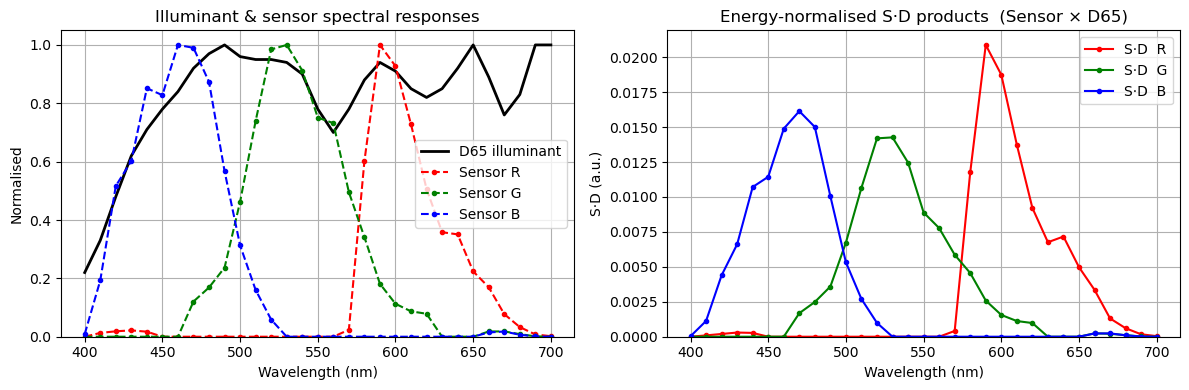

In [27]:
# Load raw sensor curves and normalise each to peak = 1
_raw = {ch: _load_sensor(ch) for ch in ("red", "green", "blue")}
for v in _raw.values():
    v[:, 1] /= v[:, 1].max()

_dl      = _load_daylight()
dl_vals  = np.interp(wl, _dl[:, 0], _dl[:, 1])
dl_vals /= dl_vals.max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: D65 illuminant + raw sensor responses
ax1.plot(wl, dl_vals, color="k", lw=2, label="D65 illuminant")
for ch, col in (("red", "r"), ("green", "g"), ("blue", "b")):
    ax1.plot(_raw[ch][:, 0], _raw[ch][:, 1], "o--", color=col, ms=3,
             label=f"Sensor {ch[0].upper()}")
ax1.set_title("Illuminant & sensor spectral responses")
ax1.set_xlabel("Wavelength (nm)");  ax1.set_ylabel("Normalised")
ax1.set_ylim(0, None);  ax1.grid(True);  ax1.legend()

# Right panel: energy-normalised S·D products
for ch, col in {"R": "r", "G": "g", "B": "b"}.items():
    ax2.plot(wl, sensor_map[ch], "o-", color=col, ms=3, label=f"S·D  {ch}")
ax2.set_title("Energy-normalised S·D products  (Sensor × D65)")
ax2.set_xlabel("Wavelength (nm)");  ax2.set_ylabel("S·D (a.u.)")
ax2.set_ylim(0, None);  ax2.grid(True);  ax2.legend()

plt.tight_layout();  plt.show()

### 3b. Longitudinal Chromatic Aberration (CHL)

The CHL curve $\mathrm{CHL}(\lambda)$ is the key lens input: it gives the axial distance ($\mu\mathrm{m}$) between the paraxial focus of wavelength $\lambda$ and the reference wavelength $\lambda_{\mathrm{ref}}$.

Two models are compared:

- **Paraxial CHL** — computed from the paraxial marginal-ray intercept $f_2'(\lambda)$:

$$\mathrm{CHL}_{\mathrm{par}}(\lambda) = \left[f_2'(\lambda) - f_2'(\lambda_{\mathrm{ref}})\right]\times 10^3 \quad (\mu\mathrm{m})$$

  This captures only the **secondary spectrum** (residual colour after achromatisation) and is independent of aperture.

- **RoRi CHL** — computed from real-ray traces at five pupil zones, weighted to approximate the best-focus position for the full aperture:

$$\mathrm{CHL}_{\mathrm{RoRi}}(\lambda) = \left[\mathrm{RoRi}(\lambda) - \mathrm{RoRi}(\lambda_{\mathrm{ref}})\right]\times 10^3 \quad (\mu\mathrm{m})$$

  This includes **spherochromatism** — the wavelength dependence of spherical aberration — and is therefore aperture-dependent.

The gap between the two curves quantifies the spherochromatism contribution. For lenses with significant SA (e.g. fast primes wide open), this gap can substantially shift the predicted fringe balance.

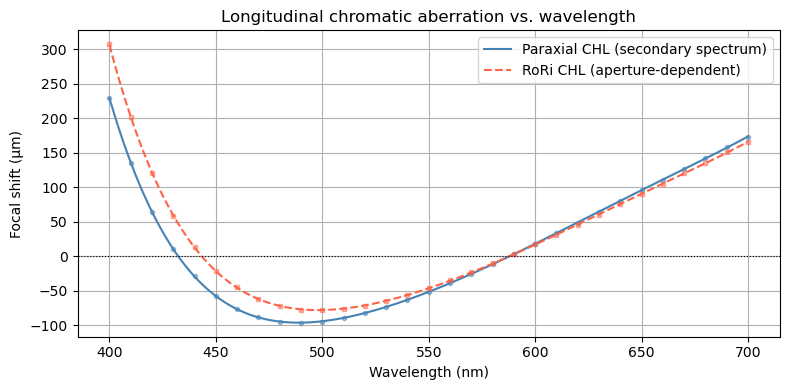

In [28]:
par_wl1  = paraxial_curve[:, 0]
par_chl1 = paraxial_curve[:, 1]
ror_wl1  = rori_curve[:, 0]
ror_chl1 = rori_curve[:, 1]

# 6th-order polynomial fits for smooth curves
wl_fit  = np.linspace(par_wl1.min(), par_wl1.max(), 300)
par_fit = np.polyval(np.polyfit(par_wl1, par_chl1, 6), wl_fit)
ror_fit = np.polyval(np.polyfit(ror_wl1, ror_chl1, 6), wl_fit)

plt.figure(figsize=(8, 4))
plt.plot(par_wl1, par_chl1, "o",  color="steelblue", ms=3, alpha=0.5)
plt.plot(wl_fit,  par_fit,  "-",  color="steelblue", label="Paraxial CHL (secondary spectrum)")
plt.plot(ror_wl1, ror_chl1, "s",  color="tomato",    ms=3, alpha=0.5)
plt.plot(wl_fit,  ror_fit,  "--", color="tomato",    label="RoRi CHL (aperture-dependent)")
plt.axhline(0, color="k", lw=0.8, ls=":")
plt.title("Longitudinal chromatic aberration vs. wavelength")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Focal shift (µm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Interactive Edge-Response Viewer

### 4.1 Per-channel ESF model

For each colour channel $c$, the polychromatic ESF is a spectrally weighted sum of monochromatic ESFs:

$$\mathrm{ESF}_c(x,z) = \sum_\lambda \hat{w}_c(\lambda) \; \mathrm{ESF}_{\mathrm{mono}}\!\left(x;\;\rho(z,\lambda)\right)$$

where $\rho(z,\lambda)$ is the **blur half-radius** at defocus $z$ for wavelength $\lambda$.

### 4.2 Blur radius

Let $N$ denote the f-number. The defocus-induced blur radius from geometric optics is:

$$\rho_{\mathrm{chl}}(z,\lambda) = \frac{|z - \mathrm{CHL}(\lambda)|}{\sqrt{4N^{2} - 1}}$$

When spherical aberration is included, the total blur combines in quadrature:

$$\rho(z,\lambda) = \sqrt{\rho_{\mathrm{chl}}(z,\lambda)^2 + \rho_{\mathrm{SA}}(\lambda)^2}$$

### 4.3 PSF shape options

Three analytic PSF shapes are available, each giving a different monochromatic ESF:

| Mode | PSF model | $\mathrm{ESF}_{\mathrm{mono}}(x;\rho)$ |
|------|-----------|----------------------------------------|
| **Pillbox** (geom) | Uniform disc | $\tfrac{1}{2}(1 + x/\rho)$, clamped to $[0,1]$ |
| **Gaussian** (gauss) | Circular Gaussian, $\sigma = 0.5\rho$ | $\tfrac{1}{2}\left[1 + \mathrm{erf}\!\left(\dfrac{x}{\sqrt{2}\,\sigma}\right)\right]$ |
| **Double Gaussian** (dgauss) | Two-zone Gaussian split at pupil radius $\rho_s$ | $w_1\,\Phi(x/\sigma_1) + w_2\,\Phi(x/\sigma_2)$ |

In the Double-Gaussian model, $w_1 = \rho_s^2$, $w_2 = 1-\rho_s^2$, and the pupil split $\rho_s$ comes from the TA-zero crossing of the Seidel defocus + SA polynomial:

$$W_{020}(z,\lambda) = -\frac{z - \mathrm{CHL}(\lambda)}{8N^{2}} \quad(\mu\mathrm{m\;OPD}), \qquad \rho_s = \sqrt{\frac{-W_{020}}{2\,W_{040}}}$$

Two additional **ray-trace** modes bypass the analytic PSF entirely and compute the ESF by direct pupil integration of pre-traced rays (see Section 2).

### 4.4 Tone mapping

The linear ESF is passed through a display tone curve before fringe detection:

$$I_{\mathrm{display}}(x) = \left[\frac{\tanh\!\left(\alpha \cdot \mathrm{ESF}(x)\right)}{\tanh(\alpha)}\right]^\gamma$$

where $\alpha$ is the exposure slope and $\gamma$ is the display gamma.

### 4.5 Colour Fringe Width (CFW)

A pixel at position $x$ is classified as **fringed** if any pair of tone-mapped channel responses differs by more than a threshold $\delta$:

$$\mathrm{Fringe}(x,z) = \mathbf{1}\!\left[\max\!\left(|R-G|,\;|R-B|,\;|G-B|\right) > \delta\right]$$

The CFW is simply the count of fringed pixels (in $\mu\mathrm{m}$, since pixel pitch = 1 $\mu\mathrm{m}$):

$$\mathrm{CFW}(z) = \sum_x \mathrm{Fringe}(x,z)$$

In [29]:
# ──────────────────────────── Display constants ─────────────────────
GAMMA_DEFAULT    = 2.2        # display gamma
EXPOSURE_DEFAULT = 1.0        # tanh-curve slope
XRANGE           = 200        # half-width of x-scan window (µm)
DEFOCUS_RANGE    = 700        # ±z sweep (µm)
DEFOCUS_STEP     = 5          # slider step (µm)
X_RES_P1         = 1          # Plot 1 sampling step (µm)
X_RES_P2         = 1          # Plot 2 sampling step (µm)
IMG_HEIGHT       = 60         # Plot 2 image height (px)

# Colour-fringe detection threshold — pixel is "fringed" when any pair of
# R/G/B channel responses differs by more than this value (0–1 scale).
COLOR_DIFF_THRESHOLD = 0.15

In [30]:
# ─────────────────────── Interactive section ───────────────────────

_PSF_LABELS = {
    "geom":          "Geometric (pillbox)",
    "gauss":         "Gaussian",
    "dgauss":        "Double Gaussian",
    "geom_fast":     "Geometric Fast (ray fan)",
    "geom_integral": "Geometric Integral (per-z trace)",
}

_out1 = widgets.Output()

def update_plots(
    z: float,
    gamma: float,
    exposure: float,
    psf_mode_choice: str,
    chl_mode: Literal["rori", "paraxial"],
    use_sa: bool,
) -> None:
    _out1.clear_output(wait=True)
    with _out1:
        chl_curve1 = rori_curve[:, 1] if chl_mode == "rori" else paraxial_curve[:, 1]
        sa_curve1  = spot_curve[:, 1] if (use_sa and chl_mode == "rori") else None
        w040_1     = w040_curve[:, 1]

        x_vals = np.arange(-XRANGE, XRANGE + X_RES_P1, X_RES_P1, dtype=float)

        def _tone(raw):
            return (np.tanh(exposure * raw) / np.tanh(exposure)) ** gamma

        if psf_mode_choice in ("geom_fast", "geom_integral"):
            if ray_fan is None and psf_mode_choice == "geom_fast":
                print("ray_fan not available (lens1 is None). Re-run data load cell.")
                return
            if psf_mode_choice == "geom_fast":
                _esf = lambda ch, x: _tone(compute_polychromatic_esf_fast(ray_fan, ch, z, x, wl_stride=3))
            else:
                _esf = lambda ch, x: _tone(compute_polychromatic_esf_geometric(lens1, ch, z, x, wl_stride=3))
            edge_r = _esf("R", x_vals)
            edge_g = _esf("G", x_vals)
            edge_b = _esf("B", x_vals)
        else:
            kw = dict(
                exposure_slope=exposure, gamma=gamma,
                chl_curve_um=chl_curve1, sa_curve_um=sa_curve1,
                f_number=FN_DEFAULT, psf_mode=psf_mode_choice,
            )
            if psf_mode_choice == "dgauss":
                kw["w040_curve_um"] = w040_1
            edge_rgb = np.array([edge_rgb_response(x, z, **kw) for x in x_vals])
            edge_r, edge_g, edge_b = edge_rgb.T

        boundaries = (
            (np.abs(edge_r - edge_g) > COLOR_DIFF_THRESHOLD) |
            (np.abs(edge_r - edge_b) > COLOR_DIFF_THRESHOLD) |
            (np.abs(edge_g - edge_b) > COLOR_DIFF_THRESHOLD)
        )
        width = int(boundaries.sum())

        fig = plt.figure(figsize=(12, 6))
        ax1 = fig.add_subplot(1, 2, 1)
        ax1.plot(x_vals, edge_r, color="r", label="R")
        ax1.plot(x_vals, edge_g, color="g", label="G")
        ax1.plot(x_vals, edge_b, color="b", label="B")
        ax1.axhline(COLOR_DIFF_THRESHOLD, color="k", ls=":", lw=1, alpha=0.5,
                    label=f"Threshold = {COLOR_DIFF_THRESHOLD:.2f}")

        jumps = np.flatnonzero(np.diff(boundaries.astype(int), prepend=boundaries[0]))
        if jumps.size:
            for idx in jumps:
                ax1.axvline(x_vals[idx], color="k", ls="--", lw=1,
                            label="Fringe boundary" if idx == jumps[0] else None)

        psf_label = _PSF_LABELS.get(psf_mode_choice, psf_mode_choice)
        if psf_mode_choice in ("geom_fast", "geom_integral"):
            chl_label, sa_label = "real ray trace (optic)", ""
        else:
            chl_label = {"rori": "RoRi (aperture-dependent)", "paraxial": "Paraxial CHL"}.get(chl_mode, chl_mode)
            sa_label  = " + SA" if sa_curve1 is not None else ""

        ax1.set(xlabel="x (µm)", ylabel="Normalised response",
                title=f"Edge responses — {psf_label}  |  {chl_label}{sa_label}",
                ylim=(0, 1))
        ax1.legend();  ax1.grid(True)

        # ---------- Plot 2: pseudo-density map ----------
        X = np.arange(-XRANGE, XRANGE + X_RES_P2, X_RES_P2, dtype=float)

        if psf_mode_choice in ("geom_fast", "geom_integral"):
            img_row = np.stack([_esf("R", X), _esf("G", X), _esf("B", X)], axis=1)
        else:
            img_row = np.array([edge_rgb_response(x, z, **kw) for x in X])

        img = np.repeat(np.clip(img_row, 0, 1)[:, None, :], IMG_HEIGHT, axis=1)

        ax2 = fig.add_subplot(1, 2, 2)
        ax2.imshow(img.swapaxes(0, 1),
                   extent=(float(X.min()), float(X.max()), 0.0, float(IMG_HEIGHT)),
                   aspect="auto", origin="lower")
        ax2.set_xlabel("x (µm)");  ax2.set_yticks([])
        if jumps.size:
            for idx in jumps:
                ax2.axvline(x_vals[idx], color="w", ls="--", lw=1, alpha=0.8)
        ax2.set_title(f"Pseudo-density fringe map  (CFW ≈ {width} µm)")

        plt.tight_layout();  plt.show()
        print(f"Colour-fringe width ≈ {width} µm  [{psf_label} | {chl_label}{sa_label}]")

# ipywidgets driver
_w1 = widgets.interactive(
    update_plots,
    z=FloatSlider(
        value=0, min=-DEFOCUS_RANGE, max=DEFOCUS_RANGE, step=DEFOCUS_STEP,
        description="Defocus (µm)", continuous_update=False),
    gamma=FloatSlider(
        value=GAMMA_DEFAULT, min=1.0, max=3.0, step=0.1,
        description="Gamma", continuous_update=False),
    exposure=FloatSlider(
        value=EXPOSURE_DEFAULT, min=1, max=8, step=1,
        description="Exposure", continuous_update=False),
    psf_mode_choice=widgets.Dropdown(
        options=[
            ("Geometric (pillbox)",            "geom"),
            ("Gaussian",                       "gauss"),
            ("Double Gaussian",                "dgauss"),
            ("Geometric Fast (ray fan)",       "geom_fast"),
            ("Geometric Integral (per-z trace, slow)", "geom_integral"),
        ],
        value="gauss",
        description="PSF model:",
    ),
    chl_mode=widgets.Dropdown(
        options=[("RoRi (aperture-dependent)", "rori"), ("Paraxial CHL", "paraxial")],
        value="rori",
        description="CHL curve:",
    ),
    use_sa=widgets.Checkbox(
        value=True,
        description="Include SA",
        tooltip="Add spherical aberration residual spot (rho_sa) in quadrature with defocus blur",
    ),
)

# Grey out CHL / SA widgets when a ray-trace mode is selected
_psf_dropdown_1 = _w1.kwargs_widgets[3]   # psf_mode_choice
_chl_dropdown_1 = _w1.kwargs_widgets[4]   # chl_mode
_sa_checkbox_1  = _w1.kwargs_widgets[5]   # use_sa

def _toggle_analytic_widgets_1(change):
    _is_raytrace = change["new"] in ("geom_fast", "geom_integral")
    _chl_dropdown_1.disabled = _is_raytrace
    _sa_checkbox_1.disabled  = _is_raytrace

_psf_dropdown_1.observe(_toggle_analytic_widgets_1, names="value")

# Display controls + dedicated output (prevents accumulation)
display(widgets.VBox([widgets.VBox(_w1.children[:-1]), _out1]))

## 5. Static Comparison Framework

The interactive viewer above shows a single defocus slice. To understand how CFW depends on defocus $z$ across the full through-focus range, we sweep $z \in [-700,\;+700]\;\mu\mathrm{m}$ and plot two metrics:

- **Left panels** — $\mathrm{CFW}(z)$ at exposures $\alpha \in \{1,2,4,8\}$: higher exposure compresses the tone curve, amplifying low-contrast fringes and increasing CFW.
- **Right panels** — Max pair difference $\max_x |I_c(x) - I_{c'}(x)|$ for each channel pair $(c,c')$: measures peak colour separation before thresholding.

The comparisons follow a **controlled-experiment** design — one variable changes at a time:

1. **5a** — Vary PSF model only (Pillbox / Gaussian / DGaussian), fix simplest inputs — isolate the effect of PSF shape assumption
2. **5b** — Fix PSF (Gaussian), progressively refine aberration inputs (Paraxial → RoRi → RoRi+SA) — isolate the effect of aberration-input accuracy
3. **5c** — All models with full inputs, including ray-fan ground truth — final cross-validation

In [31]:
# ═══════════════════════════════════════════════════════════════════
# Comparison helpers (shared by all static comparison cells below)
# ═══════════════════════════════════════════════════════════════════
_COMP_GAMMA    = GAMMA_DEFAULT
_COMP_Z_RANGE  = DEFOCUS_RANGE
_COMP_Z_STEP   = DEFOCUS_STEP
_X_ANALYTIC    = np.arange(-400, 401, dtype=float)
_CFW_EXPOSURES = (1, 2, 4, 8)       # exposures for CFW left panel
_DIFF_EXPOSURE = 4                   # fixed exposure for pair-diff right panel
_PAIR_COLORS   = {"R-G": "purple", "R-B": "darkorange", "G-B": "steelblue"}

z_vals = np.arange(-_COMP_Z_RANGE, _COMP_Z_RANGE + _COMP_Z_STEP,
                   _COMP_Z_STEP, dtype=float)

# ── Result cache (avoids recomputation across cells) ──
_cfw_cache: dict[tuple, np.ndarray] = {}
_pd_cache:  dict[tuple, dict[str, np.ndarray]] = {}


def _cache_key(psf_mode, exposure, chl_curve, sa_curve, w040):
    """Hashable key from parameters. Uses array id() since arrays persist."""
    return (psf_mode, exposure,
            id(chl_curve) if chl_curve is not None else None,
            id(sa_curve)  if sa_curve  is not None else None,
            id(w040)      if w040      is not None else None)


def _tone(raw, exposure, gamma=_COMP_GAMMA):
    return (np.tanh(exposure * raw) / np.tanh(exposure)) ** gamma


def compute_cfw_curve(
    psf_mode: str, exposure: float,
    chl_curve: np.ndarray | None = None,
    sa_curve: np.ndarray | None = None,
    w040: np.ndarray | None = None,
) -> np.ndarray:
    """Return shape (N, 2) array of [z, CFW]. Cached."""
    key = _cache_key(psf_mode, exposure, chl_curve, sa_curve, w040)
    if key in _cfw_cache:
        return _cfw_cache[key]

    if psf_mode == "geom_fast":
        def _cfw_z(z):
            esfs = [_tone(compute_polychromatic_esf_fast(ray_fan, c, z, _X_ANALYTIC, wl_stride=3), exposure)
                    for c in ("R", "G", "B")]
            fringed = ((np.abs(esfs[0] - esfs[1]) > COLOR_DIFF_THRESHOLD) |
                       (np.abs(esfs[0] - esfs[2]) > COLOR_DIFF_THRESHOLD) |
                       (np.abs(esfs[1] - esfs[2]) > COLOR_DIFF_THRESHOLD))
            return int(fringed.sum())
        result = np.array([[z, _cfw_z(z)] for z in z_vals])
    else:
        kw = dict(exposure_slope=exposure, gamma=_COMP_GAMMA,
                  chl_curve_um=chl_curve, sa_curve_um=sa_curve,
                  f_number=FN_DEFAULT, psf_mode=psf_mode,
                  color_diff_threshold=COLOR_DIFF_THRESHOLD)
        if psf_mode == "dgauss":
            kw["w040_curve_um"] = w040
        result = np.array([[z, fringe_width(z, **kw)] for z in z_vals])

    _cfw_cache[key] = result
    return result


def compute_pair_diffs(
    psf_mode: str,
    chl_curve: np.ndarray | None = None,
    sa_curve: np.ndarray | None = None,
    w040: np.ndarray | None = None,
) -> dict[str, np.ndarray]:
    """Per-pair max tone diff at fixed _DIFF_EXPOSURE. Cached."""
    key = _cache_key(psf_mode, _DIFF_EXPOSURE, chl_curve, sa_curve, w040)
    if key in _pd_cache:
        return _pd_cache[key]

    pd = {"R-G": np.zeros(len(z_vals)),
          "R-B": np.zeros(len(z_vals)),
          "G-B": np.zeros(len(z_vals))}
    for i, z in enumerate(z_vals):
        if psf_mode == "geom_fast":
            esfs = [_tone(compute_polychromatic_esf_fast(ray_fan, c, z, _X_ANALYTIC, wl_stride=3), _DIFF_EXPOSURE)
                    for c in ("R", "G", "B")]
        else:
            kw = dict(exposure_slope=_DIFF_EXPOSURE, gamma=_COMP_GAMMA,
                      chl_curve_um=chl_curve, sa_curve_um=sa_curve,
                      f_number=FN_DEFAULT, psf_mode=psf_mode)
            if psf_mode == "dgauss":
                kw["w040_curve_um"] = w040
            rgb = np.array([edge_rgb_response(x, z, **kw) for x in _X_ANALYTIC])
            esfs = [rgb[:, 0], rgb[:, 1], rgb[:, 2]]
        pd["R-G"][i] = np.abs(esfs[0] - esfs[1]).max()
        pd["R-B"][i] = np.abs(esfs[0] - esfs[2]).max()
        pd["G-B"][i] = np.abs(esfs[1] - esfs[2]).max()

    _pd_cache[key] = pd
    return pd


def plot_comparison(strategies: list[dict], suptitle: str) -> None:
    """
    One row per strategy. Left = CFW at exposures 1,2,4,8. Right = pair diff at exp=4.
    Results are cached — repeated strategies across cells cost nothing.
    """
    n = len(strategies)
    fig, axes = plt.subplots(n, 2, figsize=(14, 3.5 * n), squeeze=False,
                             sharex=True)

    cfw_max = 0
    diff_max = 0

    print(f"\n{'Strategy':40s}  {'Exp':>4}  {'max CFW':>8}  {'mean CFW':>9}  {'peak z':>7}")
    print("-" * 75)

    for row, cfg in enumerate(strategies):
        label = cfg["label"]
        kw = {k: cfg.get(k) for k in ("chl_curve", "sa_curve", "w040")}
        mode = cfg["psf_mode"]

        ax_cfw  = axes[row, 0]
        ax_diff = axes[row, 1]

        # Left: CFW at multiple exposures
        for exp in _CFW_EXPOSURES:
            cfw = compute_cfw_curve(mode, exp, **kw)
            ax_cfw.plot(cfw[:, 0], cfw[:, 1], "o-", ms=2, label=f"exp={exp}")
            cfw_max = max(cfw_max, cfw[:, 1].max())
            peak_z = cfw[cfw[:, 1].argmax(), 0]
            print(f"{label:40s}  {exp:>4}  {cfw[:, 1].max():>8.1f}  {cfw[:, 1].mean():>9.1f}  {peak_z:>+7.0f}")

        ax_cfw.set_ylabel("CFW (µm)")
        ax_cfw.set_title(label, fontsize=10, fontweight="bold")
        ax_cfw.legend(fontsize=7, ncol=2); ax_cfw.grid(True)

        # Right: pair diff at fixed exposure
        pd = compute_pair_diffs(mode, **kw)
        for pair, col in _PAIR_COLORS.items():
            ax_diff.plot(z_vals, pd[pair], "o-", ms=2, color=col, label=f"|{pair}|")
            diff_max = max(diff_max, pd[pair].max())
        ax_diff.axhline(COLOR_DIFF_THRESHOLD, color="k", ls="--", lw=1,
                        label=f"thr={COLOR_DIFF_THRESHOLD}")
        ax_diff.set_ylabel("Max tone diff")
        ax_diff.set_title(f"{label}  (exp={_DIFF_EXPOSURE})", fontsize=10, fontweight="bold")
        ax_diff.legend(fontsize=7, ncol=2); ax_diff.grid(True)

    # Sync y-limits across rows
    for row in range(n):
        axes[row, 0].set_ylim(0, cfw_max * 1.1)
        axes[row, 1].set_ylim(0, diff_max * 1.1)
    axes[-1, 0].set_xlabel("Defocus z (µm)")
    axes[-1, 1].set_xlabel("Defocus z (µm)")

    fig.suptitle(suptitle, fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout(); plt.show()

print(f"Comparison helpers ready. Cache: {len(_cfw_cache)} CFW + {len(_pd_cache)} pair-diff entries.")

Comparison helpers ready. Cache: 0 CFW + 0 pair-diff entries.


### 5a. PSF Model Comparison — Paraxial CHL, No SA

**Control variable:** PSF shape (Pillbox / Gaussian / Double-Gaussian).
**Fixed:** CHL = paraxial (no spherochromatism), SA disabled.

With identical aberration inputs, any difference in $\mathrm{CFW}(z)$ is purely due to the PSF shape assumption. The Pillbox has a sharp cutoff at $\rho$, the Gaussian has soft tails extending beyond $\rho$, and the Double-Gaussian captures the pupil-zone structure of combined defocus + SA.


Strategy                                   Exp   max CFW   mean CFW   peak z
---------------------------------------------------------------------------
Pillbox + Paraxial                           1      34.0       10.3     -110
Pillbox + Paraxial                           2      31.0        6.6     -100
Pillbox + Paraxial                           4      40.0       29.8     -510
Pillbox + Paraxial                           8      55.0       40.6     +675
Gaussian + Paraxial                          1      24.0        4.8     -115
Gaussian + Paraxial                          2      21.0        3.5     -105
Gaussian + Paraxial                          4      30.0       15.0     -310
Gaussian + Paraxial                          8      47.0       37.8     -560
DGauss + Paraxial                            1      29.0        5.3     +225
DGauss + Paraxial                            2      19.0        3.6     +245
DGauss + Paraxial                            4      44.0       23.3     +370

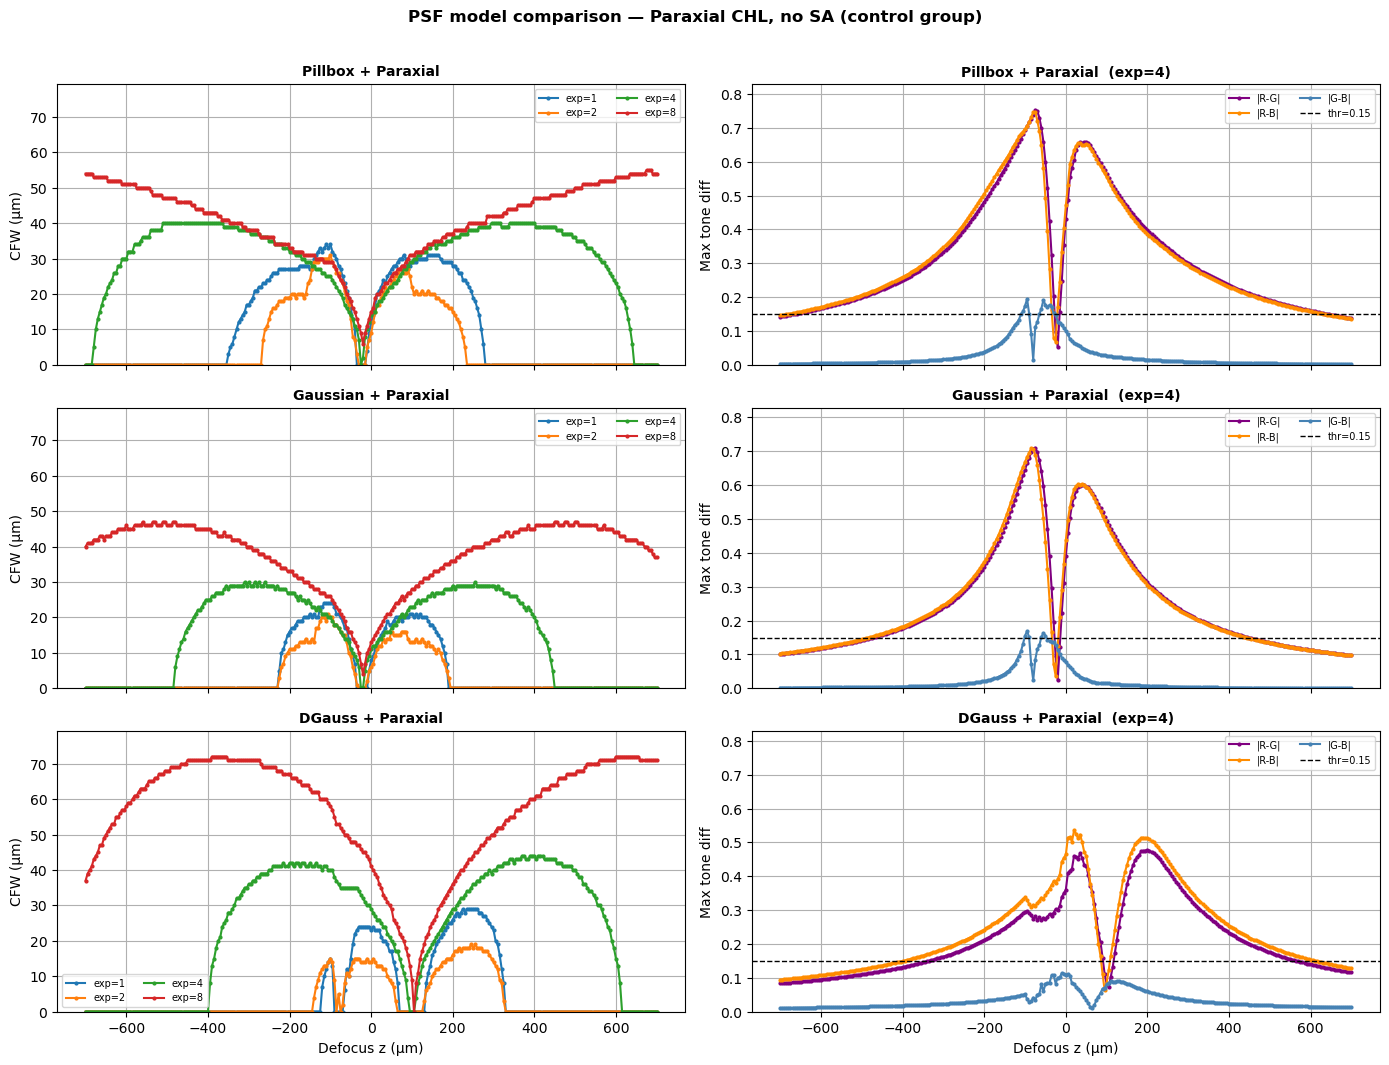

In [32]:
_chl_par = paraxial_curve[:, 1]
_w040    = w040_curve[:, 1]

plot_comparison([
    {"label": "Pillbox + Paraxial",   "psf_mode": "geom",
     "chl_curve": _chl_par, "w040": _w040},
    {"label": "Gaussian + Paraxial",  "psf_mode": "gauss",
     "chl_curve": _chl_par, "w040": _w040},
    {"label": "DGauss + Paraxial",    "psf_mode": "dgauss",
     "chl_curve": _chl_par, "w040": _w040},
], suptitle="PSF model comparison — Paraxial CHL, no SA (control group)")

### 5b. Effect of CHL Curve & Spherical Aberration

**Control variable:** aberration-input fidelity (3 levels).
**Fixed:** PSF = Gaussian.

| Row | CHL source | SA | What changes |
|-----|------------|------|-------------|
| 1 | Paraxial | off | Baseline — only secondary spectrum |
| 2 | RoRi | off | Adds spherochromatism (aperture-dependent focal shift) |
| 3 | RoRi | on | Adds residual geometric spot $\rho_{\mathrm{SA}}(\lambda)$ in quadrature |

This isolates how much the CHL accuracy and the SA-induced blur broadening each contribute to the predicted CFW.


Strategy                                   Exp   max CFW   mean CFW   peak z
---------------------------------------------------------------------------
Gaussian + Paraxial (no SA)                  1      24.0        4.8     -115
Gaussian + Paraxial (no SA)                  2      21.0        3.5     -105
Gaussian + Paraxial (no SA)                  4      30.0       15.0     -310
Gaussian + Paraxial (no SA)                  8      47.0       37.8     -560
Gaussian + RoRi (no SA)                      1      20.0        3.5      -90
Gaussian + RoRi (no SA)                      2      18.0        2.5      -85
Gaussian + RoRi (no SA)                      4      26.0       11.5     -270
Gaussian + RoRi (no SA)                      8      41.0       32.6     -505
Gaussian + RoRi + SA                         1      12.0        0.9     -125
Gaussian + RoRi + SA                         2       8.0        0.5     -115
Gaussian + RoRi + SA                         4      25.0       10.3     -265

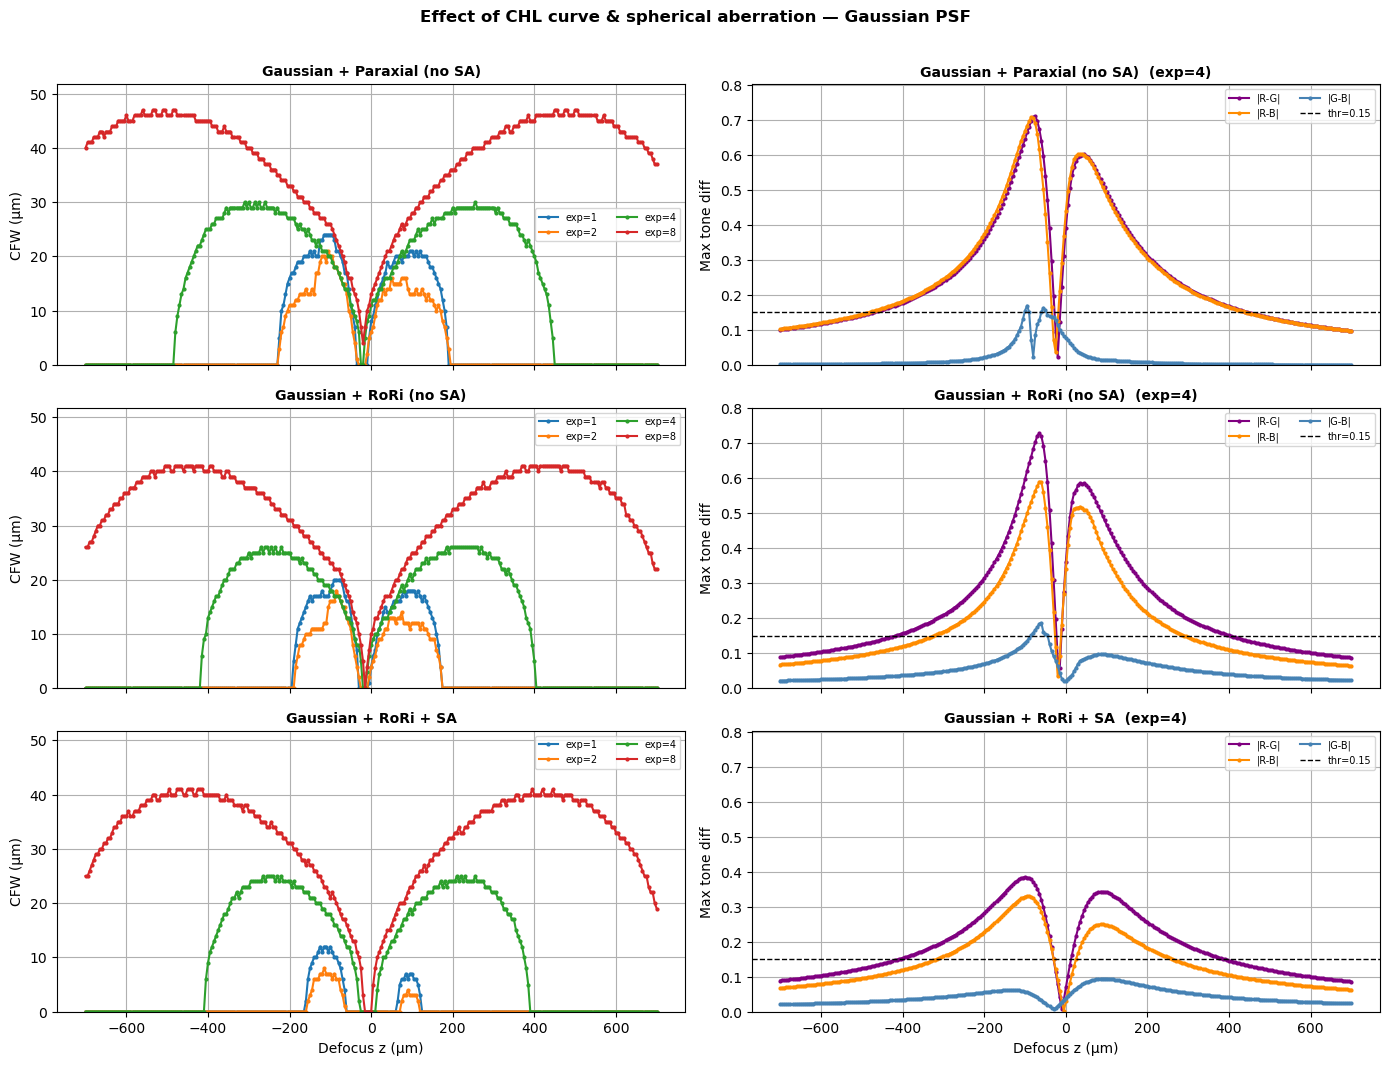

In [33]:
plot_comparison([
    {"label": "Gaussian + Paraxial (no SA)",  "psf_mode": "gauss",
     "chl_curve": paraxial_curve[:, 1]},
    {"label": "Gaussian + RoRi (no SA)",      "psf_mode": "gauss",
     "chl_curve": rori_curve[:, 1]},
    {"label": "Gaussian + RoRi + SA",         "psf_mode": "gauss",
     "chl_curve": rori_curve[:, 1], "sa_curve": spot_curve[:, 1]},
], suptitle="Effect of CHL curve & spherical aberration — Gaussian PSF")

### 5c. PSF Model Comparison — RoRi + SA (Full Inputs)

All PSF models with the most accurate analytic inputs (RoRi CHL + SA), plus the **Geometric Fast** ray-fan model which computes the ESF by direct Gauss-Legendre pupil integration:

$$\mathrm{ESF}(x;\,z,\lambda) = \sum_k \rho_k \, W_k \left[\frac{1}{\pi}\arcsin\!\left(\mathrm{clip}\!\left(\frac{x}{R(\rho_k;\,z,\lambda)},\;-1,\;1\right)\right) + \frac{1}{2}\right]$$

The ray-fan result serves as the **ground-truth reference** for the analytic approximations, since it uses the actual traced transverse aberration $R(\rho)$ at every pupil zone without assuming a particular PSF shape.


Strategy                                   Exp   max CFW   mean CFW   peak z
---------------------------------------------------------------------------
Pillbox + RoRi + SA                          1      21.0        4.9     -170
Pillbox + RoRi + SA                          2      14.0        2.1     -155
Pillbox + RoRi + SA                          4      35.0       21.5     -320
Pillbox + RoRi + SA                          8      49.0       35.8     +640
Gaussian + RoRi + SA                         1      12.0        0.9     -125
Gaussian + RoRi + SA                         2       8.0        0.5     -115
Gaussian + RoRi + SA                         4      25.0       10.3     -265
Gaussian + RoRi + SA                         8      41.0       31.7     -495
DGauss + RoRi + SA                           1      22.0        2.5     +225
DGauss + RoRi + SA                           2      14.0        1.6     +220
DGauss + RoRi + SA                           4      36.0       14.5     +350

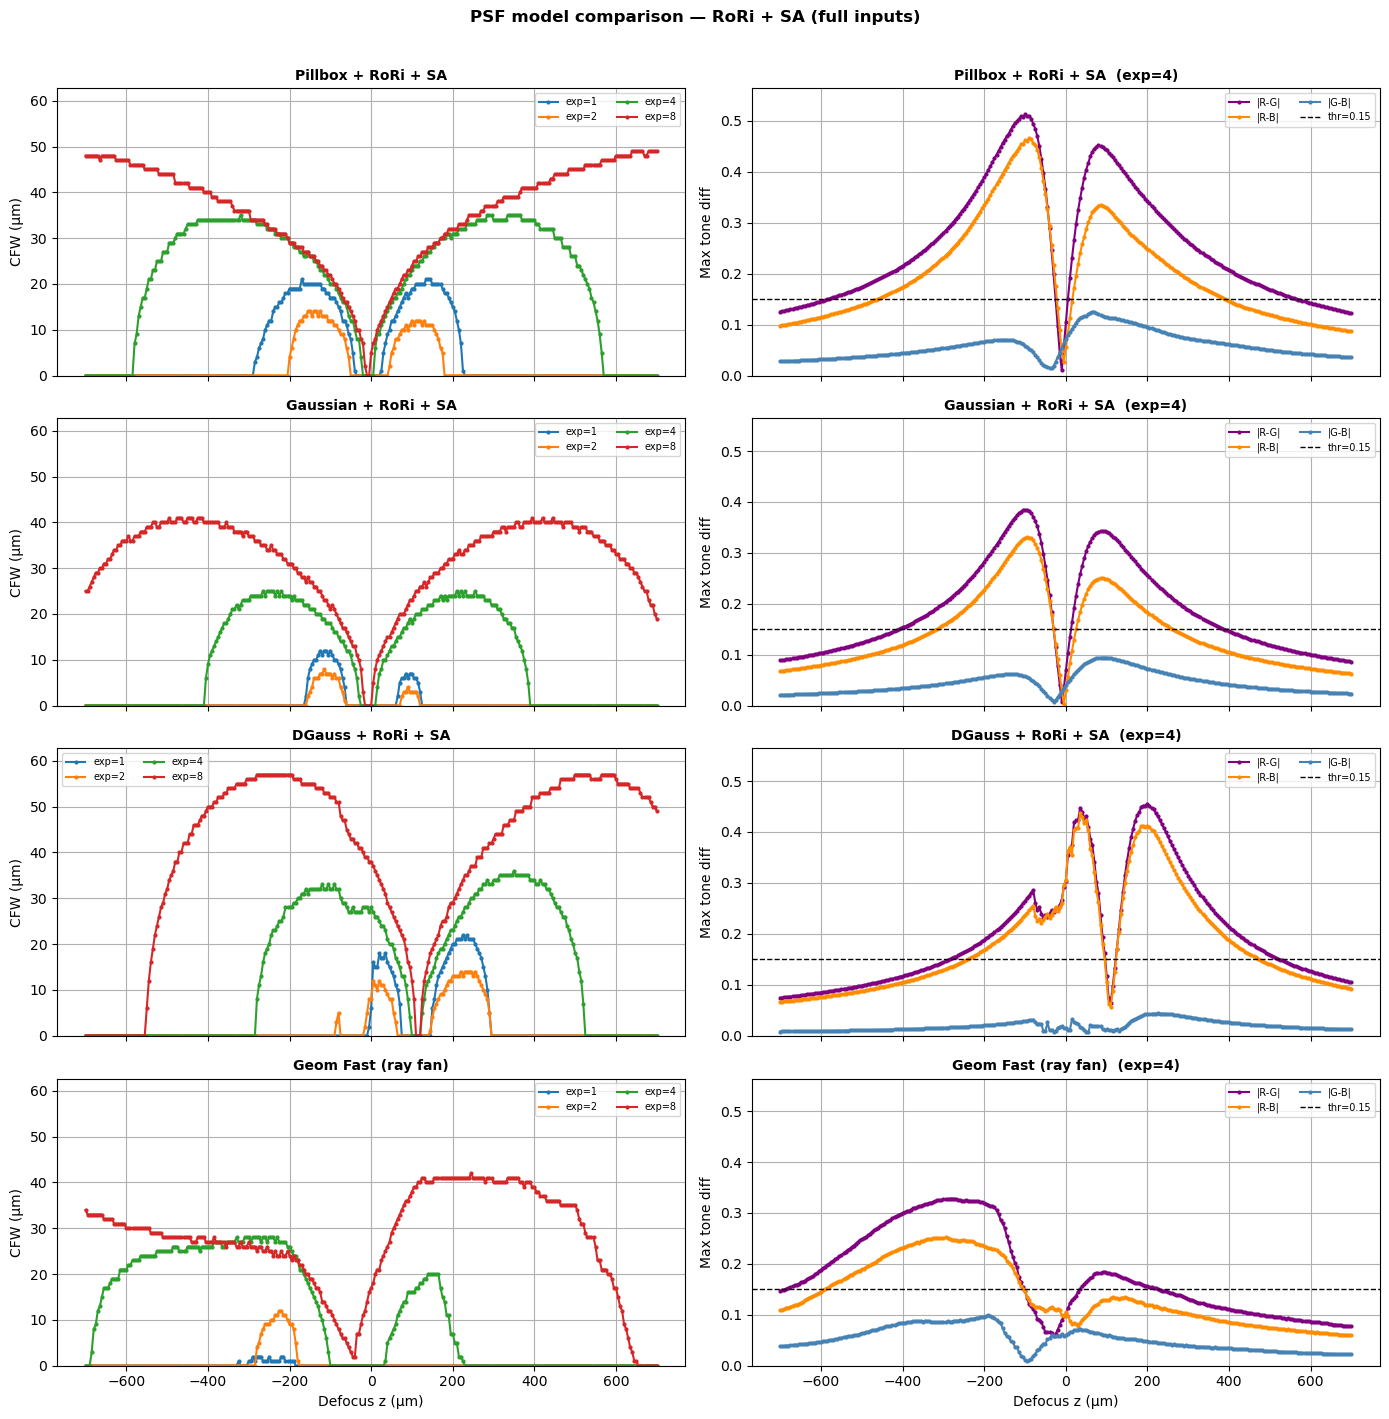

In [34]:
_w040 = w040_curve[:, 1]
_chl  = rori_curve[:, 1]
_sa   = spot_curve[:, 1]

plot_comparison([
    {"label": "Pillbox + RoRi + SA",    "psf_mode": "geom",
     "chl_curve": _chl, "sa_curve": _sa, "w040": _w040},
    {"label": "Gaussian + RoRi + SA",   "psf_mode": "gauss",
     "chl_curve": _chl, "sa_curve": _sa, "w040": _w040},
    {"label": "DGauss + RoRi + SA",     "psf_mode": "dgauss",
     "chl_curve": _chl, "sa_curve": _sa, "w040": _w040},
    {"label": "Geom Fast (ray fan)",    "psf_mode": "geom_fast"},
], suptitle="PSF model comparison — RoRi + SA (full inputs)")